#### Constants
1. SI Constants
   * $q$: Charge of a single electron.
   * $\hbar$: Reduced Planck constant.
   * $\varepsilon_0$: Vacuum permittivity.
   * $k_B$: Boltzmann constant.
   * $m_0$: Electron rest mass.
2. Transport Constants
   * $T_{\text{amb}}$: Ambient temperature
   * $\mu_0$: Low-field mobility.
   * $v_{\text{sat}}$: Saturation velocity.
3. Material Properties
   * $x_{\text{Al}}$: Aluminum mole fraction set to 0.22 (barrier layer is $\text{Al}_{0.22}\text{Ga}_{0.78}\text{N}$)
4. Bias & Electrostatics:
   * $V_{ds}$: Drain-to-source bias sets the lateral electric field ($E_x$) driving electrons to accelerate across the channel
   * $V_g$ and $V_{\text{schottky}}$: Gate bias ($0\text{ V}$) and Schottky barrier height ($1.2\text{ V}$) determine the surface potential boundary condition via:
     $$\phi_{\text{gate}} = V_g - V_{\text{schottky}} + \frac{\Delta E_c}{q}$$
     modulating the quantum well depth and 2DEG depletion.
   * $V_{\text{surface\_pin}}$: The built-in potential ($-1.2V$) caused by defects on the ungated surface that naturally depletes the 2DEG.
5. Deep Buffer Trap
   * $E_{dA}$: Trap Activation Energy ($2.5 eV$) defines the energy level of the deep acceptor trap relative to the conduction band.
   * $g_A$: Trap degeneracy factor ($4.0$), which accounts for the multiple quantum spin states available when an electron is trapped.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.sparse.linalg as spla
import scipy.linalg as la
import scipy.constants as const


# 1. PHYSICAL PARAMETERS & MATERIAL PROPERTIES
q = const.e
hbar = const.hbar
eps0 = const.epsilon_0
kB = const.k
T_amb = 300.0        # Ambient temperature (K)
m0 = const.m_e

# HEMT Operating Conditions
x_al = 0.22          # 22% Al Content
V_schottky = 1.2     # Schottky barrier height (V)
V_surface_pin = -1.2 # Fermi pinning level in access regions (V)
Vg = 0.0             # Single Gate Voltage (V)
Vds = 2.0            # Single Drain Bias (V)

# Transport Physics Parameters
mu_0 = 0.12          # low-field mobility at 300K (m^2/Vs)
v_sat_300K = 1.1e5   # Saturation velocity in GaN at 300K (m/s)
beta_CT = 2.0        # Caughey-Thomas empirical beta

# Thermal Parameters
kappa_GaN = 130.0    # Thermal conductivity of GaN (W/m-K)
kappa_AlGaN = 20.0   # Thermal conductivity of AlGaN (W/m-K)
gamma_mu = 2.0       # Temperature exponent for mobility degradation
gamma_vsat = 1.5     # Temperature exponent for velocity saturation degradation

# Deep Buffer Trap Parameters
E_dA = 2.5 * q       
g_A = 4.0

#### Material Properties
1. Effective Mass ($m^*$):
   * GaN: $m_{\text{GaN}}^* = 0.20\,m_0$.
   * AlGaN: Scales electron mass between GaN ($0.20\,m_0$) and AlN ($0.32\,m_0$) via Vegard's Law. This heavier mass in the barrier tightens quantum confinement of 2DEG.
2. Permittivity ($\varepsilon_r$):
   * GaN:  Channel dielectric constant ($\varepsilon_{\text{GaN}} = 8.9\,\varepsilon_0$)
   * AlGaN: Sets the local material permittivity from AlN ($8.5$) and GaN ($8.9$) dielectric constants using Vegard's Law.
3. Conduction Band Offset ($\Delta E_c$):
   * Stacking AlGaN on GaN creates a bandgap difference, resulting in a sharp energy step at the interface (assuming a 70% conduction-band split). This drop forms the triangular quantum well that traps electrons to build the 2DEG channel.

In [2]:
# Material parameters
m_GaN = 0.20 * m0
m_AlGaN = (0.32 * x_al + 0.20 * (1.0 - x_al)) * m0
eps_GaN = 8.9 * eps0
eps_AlGaN = (8.5 * x_al + 8.9 * (1.0 - x_al)) * eps0
dE_c = 0.7 * (3.07 * x_al + 0.7 * x_al * (1.0 - x_al)) * q  

#### 2DEG Generation from Polarization

GaN HEMTs form a 2D Electron Gas (2DEG) without chemical doping. The non-centrosymmetric wurtzite structure creates spontaneous polarization ($P_{\text{SP}}$), while the lattice mismatch between the thin AlGaN barrier and thick GaN buffer induces a biaxial tensile strain that adds piezoelectric polarization ($P_{\text{PE}}$).

1. Tensile Strain ($\eta_a$):
   *   $$\eta_a = \frac{a_{\text{GaN}} - a_{\text{AlGaN}}(x)}{a_{\text{AlGaN}}(x)}$$
   * Where $a_{\text{AlGaN}}(x)$ is interpolated via Vegard's Law using $a_{\text{GaN}} = 0.3189\text{ nm}$ and $a_{\text{AlN}} = 0.3112\text{ nm}$.

2. Piezoelectric Polarization ($P_{\text{PE}}$):
   * $$P_{\text{PE}} = 2 \eta_a \left( e_{31} - e_{33} \frac{C_{13}}{C_{33}} \right)$$
   * Combines transverse and longitudinal piezoelectric constants ($e_{31}, e_{33}$) with elastic stiffness moduli ($C_{13}, C_{33}$). The term $-\frac{C_{13}}{C_{33}}$ models vertical lattice compression ($\epsilon_z$) caused by horizontal stretching (Poisson effect).

3. Net Interface Bound Charge:
   * $$\sigma_{\text{pol}} = \frac{P_{\text{SP, GaN}} - \left( P_{\text{SP, AlGaN}}(x) + P_{\text{PE, AlGaN}} \right)}{q}$$
   * By Gauss's Law ($\nabla \cdot \mathbf{P} = -\rho_{\text{bound}}$), a spatial step-change in polarization across a dielectric interface creates a localized surface charge density: $\sigma = - (P_2 - P_1)$. 

   * Spontaneous polarization uses $P_{\text{SP, GaN}} = -0.034\text{ C/m}^2$ and $P_{\text{SP, AlGaN}}(x) = -0.090x - 0.034(1-x) + 0.021x(1-x)\text{ C/m}^2$ (with $0.021$ as a non-linear bowing factor). Because $|P_{\text{AlGaN}}| > |P_{\text{GaN}}|$, this polarization jump produces a net positive bound sheet charge ($\sigma_{\text{pol}} > 0$) at the heterojunction, pulling free electrons into the quantum well to form the 2DEG.

In [3]:
# Spontaneous & Piezoelectric Polarization
P_SP_GaN = -0.034
P_SP_AlGaN = -0.090 * x_al - 0.034 * (1.0 - x_al) + 0.021 * x_al * (1.0 - x_al)
a_GaN, a_AlN = 0.3189e-9, 0.3112e-9
a_AlGaN = a_AlN * x_al + a_GaN * (1.0 - x_al)
strain_inplane = (a_GaN - a_AlGaN) / a_AlGaN
e31 = -0.11 * x_al - 0.49 * (1.0 - x_al)
e33 = 0.73 * x_al + 0.97 * (1.0 - x_al)
C13 = (103 * x_al + 106 * (1.0 - x_al)) * 1e9
C33 = (405 * x_al + 398 * (1.0 - x_al)) * 1e9
P_PE_AlGaN = 2 * strain_inplane * (e31 - e33 * (C13 / C33))
sigma_pol = (P_SP_GaN - (P_SP_AlGaN + P_PE_AlGaN)) / q  

#### Device Geometry & Mesh Generation

Setting up a non-uniform 2D grid.

1. Depth Grid ($z$): Densely pack points around the AlGaN/GaN interface ($9–18\text{ nm}$) to catch quantum wave effects, but uses wide exponential spacing deep in the buffer where not much happens.
2. Channel Grid ($x$): Splits the length into 5 parts, adding extra points right under the gate to handle sharp electric field jumps.
3. Cell Spacing ($\Delta x_{\text{avg}}, \Delta z_{\text{avg}}$): Calculates average grid step sizes so the finite-difference math works on uneven grids.
4. 2D Properties & Contacts: Assigns material values (m_eff, eps_r, V_band) to either the top AlGaN barrier or bottom GaN buffer, and labels the top surface contacts for the Source, Gate, and Drain terminals.

In [4]:
# 2. DEVICE GEOMETRY & MESH GENERATION
L_s, L_sg, L_g, L_gd, L_d = 15e-9, 20e-9, 30e-9, 20e-9, 15e-9
Lx = L_s + L_sg + L_g + L_gd + L_d
t_barrier, t_buffer = 12.0e-9, 288.0e-9 
Lz = t_barrier + t_buffer

z_top = np.linspace(0, 9e-9, 15, endpoint=False)
z_2deg = np.linspace(9e-9, 18e-9, 65, endpoint=False) 
z_buf = np.geomspace(18e-9, Lz, 40)
z = np.unique(np.sort(np.concatenate([z_top, z_2deg, z_buf])))
Nz = len(z)

x_gate1 = L_s + L_sg
x_gate2 = x_gate1 + L_g
x_s = np.linspace(0, L_s, 10, endpoint=False)
x_sg = np.linspace(L_s, x_gate1, 15, endpoint=False)
x_g = np.linspace(x_gate1, x_gate2, 25, endpoint=False)
x_gd = np.linspace(x_gate2, Lx - L_d, 15, endpoint=False)
x_d = np.linspace(Lx - L_d, Lx, 15)
x = np.unique(np.sort(np.concatenate([x_s, x_sg, x_g, x_gd, x_d])))
Nx = len(x)

X, Z = np.meshgrid(x, z)
idx_int = np.argmin(np.abs(z - t_barrier))

dx_R = np.diff(x); dx_L = np.roll(dx_R, 1)                  
dx_avg = 0.5 * (np.append(dx_R, dx_R[-1]) + np.insert(dx_L, 0, dx_L[0]))
dz_R = np.diff(z); dz_L = np.roll(dz_R, 1)                  
dz_avg = 0.5 * (np.append(dz_R, dz_R[-1]) + np.insert(dz_L, 0, dz_L[0]))

m_eff = np.where(Z <= t_barrier, m_AlGaN, m_GaN)
eps_r = np.where(Z <= t_barrier, eps_AlGaN, eps_GaN)
kappa_grid = np.where(Z <= t_barrier, kappa_AlGaN, kappa_GaN)
V_band = np.where(Z <= t_barrier, dE_c, 0.0)

source_mask = (X <= L_s) & (Z == 0)
gate_mask = (X >= x_gate1) & (X <= x_gate2) & (Z == 0)
drain_mask = (X >= Lx - L_d) & (Z == 0)

#### Doping

This section populates the fixed space-charge grid ($\rho_{\text{fixed}}$), the right-hand side term for the Poisson equation.

1. Polarization to Volumetric Charge: Divide the 2D interface sheet charge by the average thickness step size.
   $$\rho_{\text{int}} = \frac{q \sigma_{\text{pol}}}{\Delta z_{\text{avg}}}$$
2. Deep Buffer Acceptors Doping:
   * GaN naturally grows with defects that release stray electrons, causing off-state leakage.
   * Deep Carbon acceptors ($N_A = 5 \times 10^{16}\text{ cm}^{-3}$) are doped deep into the buffer that create empty energy states in the middle of the bandgap to trap the stray electrons.
   * Therefore, the Fermi level is anchored mid-gap, turning the bulk buffer into an insulator.
3. Contact Doping:
   * The Source and Drain are heavily doped ($N_D = 2 \times 10^{19}\text{ cm}^{-3}$) to form Ohmic contacts.
   * When donor density exceeds the conduction band's effective density of states ($N_C$), the material physics shifts from classical to quantum.
4. Degeneracy, Pauli Blocking & The Joyce-Dixon Derivation:
   * According to Pauli's Exclusion Principle, fermions cannot share the same quantum state. Since the lowest available energy states are completely filled, the remaining electrons are forced into higher energy levels, making the semiconductor degenerate.
   * Standard Boltzmann statistics ignore this quantum crowding. The exact electron density is found by integrating the 3D parabolic density of states against the Fermi-Dirac distribution, yielding the Fermi-Dirac integral of order 1/2:
     $$F_{1/2}(\eta) = \int_0^\infty \frac{x^{1/2}}{1 + e^{x-\eta}} dx \approx \frac{\sqrt{\pi}}{2} \left( e^\eta - \frac{e^{2\eta}}{2^{3/2}} \right)$$
     where $x = \frac{E - E_C}{k_B T}$ is the normalized kinetic energy, and $\eta = \frac{E_F - E_C}{k_B T} = \frac{q V_{\text{bi}}}{k_B T_{\text{amb}}}$ is the reduced Fermi energy.
   * Substituting the expanded integral relates carrier density to $\eta$:
     $$\frac{n}{N_C} = \frac{2}{\sqrt{\pi}} F_{1/2}(\eta) \approx e^\eta - \frac{e^{2\eta}}{\sqrt{8}}$$
   * To solve for the Fermi energy given a heavy doping concentration ($n \approx N_D$), we mathematically invert the series to find the first-order correction:
     $$\eta \approx \ln\left(\frac{N_D}{N_C}\right) + \frac{N_D}{N_C \sqrt{8}}$$
   * Substituting $\eta$ gives the final Joyce-Dixon approximation used to calculate the built-in potential ($V_{\text{bi}}$):
     $$V_{\text{bi}} = \frac{k_B T_{\text{amb}}}{q} \left( \ln\left(\frac{N_D}{N_C}\right) + \frac{N_D}{N_C \sqrt{8}} \right)$$
   * Classical Term $\left[ \ln(N_D / N_C) \right]$: The standard Maxwell-Boltzmann calculation which ignores quantum crowding.
   * The Quantum Correction $\left[ \frac{N_D}{N_C \sqrt{8}} \right]$: The Joyce-Dixon penalty factor corrects for Pauli blocking, adding extra electrical potential to account for the fact that new electrons are forced into higher energy states because the lower ones are full.
   * $N_C$: The effective density of states, calculated as $2 \left( \frac{m_{\text{GaN}}^* k_B T_{\text{amb}}}{2\pi\hbar^2} \right)^{3/2}$.

In [5]:
# 3. DOPING
rho_fixed = np.zeros((Nz, Nx))
rho_fixed[idx_int+1:, :] += q * 1e22 
rho_fixed[idx_int, :] += (q * sigma_pol) / dz_avg[idx_int]

N_D_contacts = 2e25 
contact_depth = t_barrier + 2e-9
rho_fixed[(X <= L_s) & (Z <= contact_depth)] += q * N_D_contacts
rho_fixed[(X >= Lx - L_d) & (Z <= contact_depth)] += q * N_D_contacts

t_buffer_doped_start = t_barrier + 20e-9
idx_buffer_doped = np.max(np.where(z <= t_buffer_doped_start)[0])
N_acceptor = 5e22 

buf_trap_mask = np.zeros((Nz, Nx), dtype=bool)
buf_trap_mask[idx_buffer_doped:, :] = True

N_C_GaN = 2.0 * ((m_GaN * kB * T_amb) / (2.0 * np.pi * hbar**2))**1.5 
n_ratio = N_D_contacts / N_C_GaN
V_bi = (kB * T_amb / q) * (np.log(n_ratio) + n_ratio / np.sqrt(8))

#### 4. 2D Matrices (Poisson & Thermal)

To solve for electrostatic potential ($V$) and lattice temperature ($T$), the 2D grid is flattened into a 1D vector ($k = j \cdot N_x + i$):
$$ \begin{bmatrix} (0,0) & (1,0) & (2,0) \\ (0,1) & \mathbf{(1,1)} & (2,1) \\ (0,2) & (1,2) & (2,2) \end{bmatrix} \quad \xrightarrow{\text{flatten}} \quad \begin{bmatrix} 0 & 1 & 2 \\ 3 & \mathbf{4} & 5 \\ 6 & 7 & 8 \end{bmatrix} $$
1. The 5-Point Stencil:
  An interior node ($k=4$) couples only to its four physical neighbors. Its row in the solver matrix ($A$) stores these coupling coefficients ($C$):
  $$A_{\text{row } 4} = \left[ \dots,\ \underbrace{C_{\text{Top}}}_{k=1},\ \dots,\ \underbrace{C_{\text{Left}}}_{k=3},\ \underbrace{-\sum C}_{\mathbf{k=4}},\ \underbrace{C_{\text{Right}}}_{k=5},\ \dots,\ \underbrace{C_{\text{Bot}}}_{k=7},\ \dots \right]$$
   * Poisson Matrix ($C = c$): Coefficients are dictated by permittivity ($\epsilon_r$) to govern electric field propagation.
   * Thermal Matrix ($C = tc$): Coefficients are dictated by thermal conductivity ($\kappa$) to govern heat flow.

2. Boundary Conditions:
   * Dirichlet: The matrix diagonal is set to $1.0$, mathematically locking the node to the applied voltage or ambient temperature.
   * Neumann: The diagonal is set to $1.0$ and the neighbor to $-1.0$. This forces a zero-gradient, strictly preventing fields or heat from leaking out of the simulation box:

In [6]:
# 4. 2D MATRICES (POISSON & THERMAL)
N_tot = Nx * Nz
A_poisson_base = sparse.lil_matrix((N_tot, N_tot))
A_therm_base = sparse.lil_matrix((N_tot, N_tot))

def get_k(i, j): return j * Nx + i

for j in range(Nz):
    for i in range(Nx):
        k = get_k(i, j)
        
        # Poisson Stencil Setup
        if gate_mask[j, i] or source_mask[j, i] or drain_mask[j, i] or j == 0:
            A_poisson_base[k, k] = 1.0
        elif j == Nz - 1: 
            A_poisson_base[k, k] = 1.0; A_poisson_base[k, get_k(i, j-1)] = -1.0
        elif i == 0:      
            A_poisson_base[k, k] = 1.0; A_poisson_base[k, get_k(i+1, j)] = -1.0
        elif i == Nx - 1: 
            A_poisson_base[k, k] = 1.0; A_poisson_base[k, get_k(i-1, j)] = -1.0
        else:
            dx_r_i, dx_l_i, dx_a_i = dx_R[i], dx_R[i-1], dx_avg[i]
            dz_r_j, dz_l_j, dz_a_j = dz_R[j], dz_R[j-1], dz_avg[j]
            
            exP = 0.5 * (eps_r[j, i] + eps_r[j, i+1]); exM = 0.5 * (eps_r[j, i] + eps_r[j, i-1])
            ezP = 0.5 * (eps_r[j, i] + eps_r[j+1, i]); ezM = 0.5 * (eps_r[j, i] + eps_r[j-1, i])
            c_iP, c_iM = exP / (dx_a_i * dx_r_i), exM / (dx_a_i * dx_l_i)
            c_jP, c_jM = ezP / (dz_a_j * dz_r_j), ezM / (dz_a_j * dz_l_j)
            A_poisson_base[k, get_k(i+1, j)] = c_iP; A_poisson_base[k, get_k(i-1, j)] = c_iM
            A_poisson_base[k, get_k(i, j+1)] = c_jP; A_poisson_base[k, get_k(i, j-1)] = c_jM
            A_poisson_base[k, k] = -(c_iP + c_iM + c_jP + c_jM)

        # Thermal Stencil Setup
        if j == Nz - 1:   
            A_therm_base[k, k] = 1.0
        elif i == 0:      
            A_therm_base[k, k] = 1.0; A_therm_base[k, get_k(i+1, j)] = -1.0
        elif i == Nx - 1: 
            A_therm_base[k, k] = 1.0; A_therm_base[k, get_k(i-1, j)] = -1.0
        elif j == 0:      
            A_therm_base[k, k] = 1.0; A_therm_base[k, get_k(i, j+1)] = -1.0
        else:
            dx_r_i, dx_l_i, dx_a_i = dx_R[i], dx_R[i-1], dx_avg[i]
            dz_r_j, dz_l_j, dz_a_j = dz_R[j], dz_R[j-1], dz_avg[j]
            
            kxP = 0.5 * (kappa_grid[j, i] + kappa_grid[j, i+1]); kxM = 0.5 * (kappa_grid[j, i] + kappa_grid[j, i-1])
            kzP = 0.5 * (kappa_grid[j, i] + kappa_grid[j+1, i]); kzM = 0.5 * (kappa_grid[j, i] + kappa_grid[j-1, i])
            tc_iP, tc_iM = kxP / (dx_a_i * dx_r_i), kxM / (dx_a_i * dx_l_i)
            tc_jP, tc_jM = kzP / (dz_a_j * dz_r_j), kzM / (dz_a_j * dz_l_j)
            A_therm_base[k, get_k(i+1, j)] = tc_iP; A_therm_base[k, get_k(i-1, j)] = tc_iM
            A_therm_base[k, get_k(i, j+1)] = tc_jP; A_therm_base[k, get_k(i, j-1)] = tc_jM
            A_therm_base[k, k] = -(tc_iP + tc_iM + tc_jP + tc_jM)

A_csr = A_poisson_base.tocsr()
A_therm_csr = A_therm_base.tocsr()

#### Electro-Thermal Gummel Loop

The Gummel Loop is a numerical strategy that decouples electrostatic potential ($V$), quantum electron density ($n$), and lattice temperature ($T$), solving them sequentially until the entire device reaches a stable equilibrium.
1. Electrostatics & Dynamic Traps (Poisson Block)
   * Poisson Equation:
$$ \nabla \cdot (\epsilon \nabla \phi) = -(\rho_{\text{fixed}} + \rho_{\text{trap}}(\phi) - q n_{\text{2d}}(\phi)) $$
   * Dynamic Trap Ionization: The GaN buffer layer contains deep acceptor traps that become negatively charged when they trap an electron, which is governed by Fermi-Dirac statistics:
   $$ f_A = \frac{1}{1 + g_A \exp\left(\frac{E_A - E_{Fn}}{k_B T}\right)} $$
   * The Gummel Damping Method: Because charge depends exponentially on potential, standard solvers diverge. The Gummel method stabilizes the solver using a Newton-Raphson Taylor expansion of the charge:
$$ \rho(\phi_{\text{new}}) \approx \rho(\phi_{\text{old}}) + \frac{\partial \rho}{\partial \phi} (\phi_{\text{new}} - \phi_{\text{old}}) $$
Substituting this into the Poisson equation isolates the new potential with a damping factor $D = -\frac{\partial \rho}{\partial \phi}$:
$$ \nabla \cdot (\epsilon \nabla \phi_{\text{new}}) + D \phi_{\text{new}} = -\rho(\phi_{\text{old}}) + D \phi_{\text{old}} $$
   * Damping Derivatives: Using the chain rule, the analytical derivatives for both the dynamic traps ($f_A$) and the free electrons ($n_{\text{2d}}$) are derived to find the total damping factor $D$:
$$ D_{\text{trap}} = \frac{q^2 N_A}{k_B T} \frac{X}{(1+X)^2} \quad \text{where } X = g_A \exp\left(\frac{E_A - E_{Fn}}{k_B T}\right) $$
$$ D_{\text{electrons}} = \frac{q^2 N_C}{k_B T} \left( 1 - \exp\left(-\frac{n_{\text{2d}}}{N_C}\right) \right) $$
   * Matrix Setup: To solve this computationally, the combined damping factor $D$ is subtracted from the diagonal of the inherently negative static Poisson matrix ($A$). This mathematically anchors the solver to prevent wild voltage swings:
$$ (A + D) \phi_{\text{new}} = b_{\text{old}} + D \phi_{\text{old}} $$
2. Quantum Confinement (Schrödinger Block)
   * At the AlGaN/GaN heterojunction, electrons are pulled into a valley just a few nanometers wide, forming a 2D Electron Gas (2DEG) confined to discrete quantum energy subbands ($E_m$).
   * Schrödinger's Equation (Ben Daniel-Duke Hamiltonian): 
   $$ \left[ -\frac{\hbar^2}{2} \frac{\partial}{\partial z} \left( \frac{1}{m^*(z)} \frac{\partial}{\partial z} \right) + V_{\text{eff}}(z) \right] \psi_m(z) = E_m \psi_m(z) $$
   This equation accounts for the changing effective mass ($m^*(z)$) across the heterojunction.
   * Effective Potential ($V_{\text{eff}}$): Electrons are packed so tightly they repel each other. This is modeled by adding an Exchange-Correlation potential ($V_{xc}$) to the total electrostatic potential ($V_{\text{tot}}$):
   $$ V_{\text{eff}} = V_{\text{tot}} + V_{xc} \quad \text{where} \quad V_{xc} = -\frac{q^2}{4 \pi \varepsilon_r} \left( \frac{3 n_{\text{old}}}{\pi} \right)^{1/3} $$
   * Discretization of Kinetic Energy: The inner spatial derivative is approximated on a non-uniform grid by taking the flux difference between the right and left midpoints:
   $$ \text{KE}_j \approx -\frac{\hbar^2}{2 \Delta z_{\text{avg},j}} \left[ \left\langle \frac{1}{m^*} \right\rangle_{j+1/2} \frac{\psi_{j+1} - \psi_j}{\Delta z_{R,j}} - \left\langle \frac{1}{m^*} \right\rangle_{j-1/2} \frac{\psi_j - \psi_{j-1}}{\Delta z_{L,j}} \right] $$
   * Matrix Setup: To ensure the resulting matrix is symmetric for rapid eigenvalue solving, a $\sqrt{\Delta z}$ transformation is applied, resulting in a Tridiagonal Matrix:
   $$ \begin{bmatrix} \mathbf{D_1} & E_1 & 0 & 0 & 0 \\ E_1 & \mathbf{D_2} & E_2 & 0 & 0 \\ 0 & E_2 & \mathbf{D_3} & E_3 & 0 \\ 0 & 0 & E_3 & \mathbf{D_4} & E_4 \\ 0 & 0 & 0 & E_4 & \mathbf{D_5} \end{bmatrix} \begin{bmatrix} \psi_1 \\ \psi_2 \\ \psi_3 \\ \psi_4 \\ \psi_5 \end{bmatrix} = E_m \begin{bmatrix} \psi_1 \\ \psi_2 \\ \psi_3 \\ \psi_4 \\ \psi_5 \end{bmatrix} $$
   The Main Diagonal ($D_j$) represents the local potential plus the kinetic penalty of being localized at node $j$:
   $$ D_j = V_{\text{eff},j} + \frac{\hbar^2}{2 \Delta z_{\text{avg},j}} \left[ \frac{\langle 1/m^* \rangle_{j+1/2}}{\Delta z_{R,j}} + \frac{\langle 1/m^* \rangle_{j-1/2}}{\Delta z_{L,j}} \right] $$
   The Off-Diagonal ($E_j$) represents the kinetic energy reward for an electron wave spreading to the next node:
   $$ E_j = -\frac{\hbar^2}{2} \frac{\langle 1/m^* \rangle_{j+1/2}}{\Delta z_{R,j} \sqrt{\Delta z_{\text{avg},j} \Delta z_{\text{avg},j+1}}} $$
   * Subband Population: The number of electrons in each subband ($n_s^{(m)}$) is found by integrating the 2D Density of States ($g(E)$) with the Fermi-Dirac probability function ($f(E)$):
   $$ n_s^{(m)} = \int_{E_m}^{\infty} g(E) f(E) dE \quad \text{where} \quad g(E) = \frac{m^*}{\pi \hbar^2}, \;\; f(E) = \frac{1}{1 + \exp\left(\frac{E - E_{Fn}}{k_B T}\right)} $$
   Evaluating this integral yields the exact 2D sheet density per subband:
   $$ n_s^{(m)} = \frac{m^* k_B T}{\pi \hbar^2} \ln\left(1 + \exp\left(\frac{E_{Fn} - E_m}{k_B T}\right)\right) $$
   * Final Density Reconstruction: The total 3D electron cloud is rebuilt by multiplying the subband population by the physical probability density (the wavefunction squared):
   $$ n_{\text{new}}(z) = \sum_m n_s^{(m)} |\psi_m(z)|^2 $$
3. Electro-Thermal Transport:
Once the quantum states dictate where the electrons are, this block calculates how fast they move laterally ($x$-direction) and how much heat they generate.
   * Mobility & Thermal Degradation:
   The electron mobility ($\mu$) is physically degraded by several scattering mechanisms (dislocations, phonons, and interface roughness). These are combined via Matthiessen's Rule and scaled by the local lattice temperature ($T$):
   $$\mu_0(T, x) = \left( \frac{1}{\mu_{\text{dis}}(n_s)} + \frac{1}{\mu_{\text{pop}}} + \frac{1}{\mu_{\text{irs}}(n_s)} \right)^{-1} \times \left(\frac{T_{\text{amb}}}{T(x)}\right)^{\gamma_\mu}$$
   Similarly, the maximum terminal speed of the electrons drops as the lattice heats up:
   $$v_{\text{sat}}(T) = v_{\text{sat,300K}} \left( \frac{T_{\text{amb}}}{T(x)} \right)^{\gamma_{vsat}}$$
   
   * Drift Velocity ($v_d$) & Caughey-Thomas Model:
   The speed of the electrons depends on the lateral electric field ($E_x$):
      * Low Field: Electrons accelerate linearly, obeying Ohm's Law: $v_d \approx \mu_0(T) |E_x|$.
      * High Field: Electrons violently emit optical phonons, hitting a strict speed limit: $v_d \to v_{\text{sat}}(T)$.
   To smoothly bridge these two regimes, the mobility is further degraded using the Caughey-Thomas formula:
   $$\mu_{\text{field}}(x) = \frac{\mu_0(T, x)}{\left[ 1 + \left( \frac{\mu_0(T, x) \cdot |E_x|}{v_{\text{sat}}(T)} \right)^\beta \right]^{1/\beta}}$$

   * Current Solving (Kirchhoff's Current Law):
   Current is driven by the gradient of the quasi-Fermi level ($V_{ef}$):
   $$I_D = q n_s \mu_{\text{field}}(E_x, T) \frac{dV_{ef}}{dx}$$
   By defining the channel conductance as $G_{\text{eff}} = q n_s \mu_{\text{field}}$, Kirchhoff's Current Law requires the 1D spatial divergence to be zero:
   $$\frac{d}{dx} \left( G_{\text{eff}}(x) \frac{dV_{ef}}{dx} \right) = 0$$
   Integrating across a single grid node $i$, the flux leaving the right midpoint minus the flux entering the left midpoint must equal zero:
   $$\left[ G_{\text{eff}} \frac{dV_{ef}}{dx} \right]_{i+1/2} - \left[ G_{\text{eff}} \frac{dV_{ef}}{dx} \right]_{i-1/2} = 0$$
   The derivatives at these midpoints are approximated using discrete finite differences:
   $$\left.\frac{dV_{ef}}{dx}\right|_{i+1/2} \approx \frac{V_{ef, i+1} - V_{ef, i}}{\Delta x_{R, i}} \quad \text{and} \quad \left.\frac{dV_{ef}}{dx}\right|_{i-1/2} \approx \frac{V_{ef, i} - V_{ef, i-1}}{\Delta x_{L, i}}$$
   By substituting these finite slopes, we get the exact flux balance equation used to structure the tridiagonal matrix:
   $$L_C V_{ef, i-1} - (L_C + R_C) V_{ef, i} + R_C V_{ef, i+1} = 0$$
   where $L_C = \frac{G_{\text{eff}, i-1/2}}{\Delta x_{L, i}}$ and $R_C = \frac{G_{\text{eff}, i+1/2}}{\Delta x_{R, i}}$.

   * Joule Heating:
   $$\nabla \cdot (\kappa \nabla T) = - (J \cdot E_x)$$
   The kinetic energy lost from electrons into the lattice during velocity saturation becomes heat from severe lattice vibrations. This volumetric power dissipation ($P_{\text{diss}} = J \cdot E_x$) creates a localized hotspot at the drain edge of the gate. 

4. The Final Feedback Loop: This hotspot raises the local lattice temperature ($T$), which increases phonon scattering, severely reducing the mobility, and shifts the quasi-Fermi levels. The simulation loops continuously until it is self-consistent.

In [7]:
# 5. SINGLE BIAS POINT ELECTRO-THERMAL GUMMEL LOOP
max_iter_limit = 3000
min_iters = 250
n_subbands = 3

window_size = 5
convergence_tol = 1e-4  # mA/mm tolerance
max_diverge_steps = 3
trend_window_size = max_diverge_steps * 2

alpha_p, alpha_n, alpha_EF, alpha_T = 0.05, 0.025, 0.025, 0.02

print("\n" + "="*60)
print(f" STARTING SINGLE BIAS RUN (VGS = {Vg} V, VDS = {Vds} V)")
print("="*60)

Id_history = []
moving_avg_prev = None
diverge_count = 0
best_stable_Id = 0.0
recent_trends = []

phi = np.zeros((Nz, Nx))
n_2d = np.zeros((Nz, Nx))
T_2d = np.full((Nz, Nx), T_amb)
T_channel = np.full(Nx, T_amb)
V_tot = np.copy(V_band)

V_ef_lat = np.linspace(0, Vds, Nx)
E_F_lat = -q * V_ef_lat

idx_qbox = np.argmin(np.abs(z - (t_barrier + 95.0e-9)))

dirichlet_mask = gate_mask | source_mask | drain_mask
surface_pin_mask = (Z == 0) & ~dirichlet_mask
outer_bc_mask = ((Z == Lz) | (X == 0) | (X == Lx)) & (Z > 0)
interior_mask = ~(dirichlet_mask | surface_pin_mask | outer_bc_mask)

N_DOS_3D_equiv = np.broadcast_to((m_GaN * kB * T_amb) / (np.pi * hbar**2 * dz_avg[:, np.newaxis]), (Nz, Nx))
b_base_2d = np.zeros((Nz, Nx))
b_base_2d[gate_mask] = Vg - (V_schottky - dE_c / q)
b_base_2d[source_mask] = V_bi
b_base_2d[drain_mask] = Vds + V_bi
b_base_2d[surface_pin_mask] = V_surface_pin

Ex_abs = np.zeros(Nx)
mu_field = np.zeros(Nx)
I_d_channel = np.zeros(Nx)
I_d_avg = 0.0

# Storage for gate center analysis (x ~ 50 nm)
i_gate_center = np.argmin(np.abs(x - (x_gate1 + L_g / 2)))
evals_gate_center = np.zeros(n_subbands)
n_subbands_gate_center = np.zeros((n_subbands, Nz))

for iteration in range(max_iter_limit):
    # A. Poisson Block
    b_2d = np.copy(b_base_2d)
    E_C = V_band - q * phi; E_A = E_C - E_dA
    E_Fn = E_F_lat[np.newaxis, :] 
    
    exp_term_A = g_A * np.exp(np.clip((E_A - E_Fn) / (kB * T_amb), -700.0, 700.0))
    f_A = 1.0 / (1.0 + exp_term_A) 
    
    rho_trap = np.zeros((Nz, Nx))
    rho_trap[buf_trap_mask] = -q * N_acceptor * f_A[buf_trap_mask]
    
    rho_total = rho_fixed + rho_trap
    b_2d[interior_mask] = -(rho_total[interior_mask] - q * n_2d[interior_mask])
    
    term_n = np.exp(-np.minimum(n_2d[interior_mask] / N_DOS_3D_equiv[interior_mask], 700.0))
    D_electrons = (q**2 * N_DOS_3D_equiv[interior_mask] / (kB * T_amb)) * (1.0 - term_n)
    
    exp_A_sub = exp_term_A[buf_trap_mask]
    df_dE = np.where(
        exp_A_sub > 1e15, 
        0.0, 
        exp_A_sub / (1.0 + exp_A_sub)**2
    )
    
    D_traps = np.zeros((Nz, Nx))
    D_traps[buf_trap_mask] = (q**2 * N_acceptor / (kB * T_amb)) * df_dE
    
    D_gummel_2d = np.zeros((Nz, Nx))
    D_gummel_2d[interior_mask] = D_electrons + D_traps[interior_mask]
    
    D_gummel_flat = D_gummel_2d.flatten()
    A_gummel_dynamic = A_csr - sparse.diags(D_gummel_flat, format='csr')
    b_gummel_dynamic = b_2d.flatten() - D_gummel_flat * phi.flatten()
    
    phi_new = spla.spsolve(A_gummel_dynamic, b_gummel_dynamic).reshape((Nz, Nx))
    err_phi = np.max(np.abs(phi_new - phi))
    
    phi = alpha_p * phi_new + (1 - alpha_p) * phi
    V_tot = np.clip(V_band - q * phi, -15 * q, 5 * q) 
    
    # B. Schrödinger Block
    n_new = np.zeros((Nz, Nx))
    V_xc_raw = -(q**2 / (4.0 * np.pi * eps_r)) * (3.0 * np.maximum(n_2d, 1e12) / np.pi)**(1.0 / 3.0)
    V_xc = np.clip(V_xc_raw, -0.05 * q, 0.0)
    V_quantum_2d = V_tot + V_xc
    N_int = idx_qbox - 2
    
    for i in range(Nx):
        V_quantum = V_quantum_2d[:idx_qbox, i]; m_col = m_eff[:idx_qbox, i]
        d_int = np.zeros(N_int); e_int = np.zeros(N_int - 1)
        
        for k in range(N_int):
            j = k + 1
            dz_r, dz_l, dz_a = dz_R[j], dz_R[j-1], dz_avg[j]
            inv_mp, inv_mm = 0.5*(1.0/m_col[j] + 1.0/m_col[j+1]), 0.5*(1.0/m_col[j] + 1.0/m_col[j-1])
            d_int[k] = V_quantum[j] + (hbar**2 / (2.0 * dz_a)) * (inv_mp / dz_r + inv_mm / dz_l)
            if k < N_int - 1:
                e_int[k] = -(hbar**2 / 2.0) * (inv_mp / dz_r) / np.sqrt(dz_a * dz_avg[j+1])
        
        evals, evecs_int = la.eigh_tridiagonal(d_int, e_int, select='i', select_range=(0, n_subbands-1))
        evecs_full = np.zeros((idx_qbox, n_subbands))
        evecs_full[1:-1, :] = evecs_int
        
        if i == i_gate_center:
            evals_gate_center = np.copy(evals)
            n_subbands_gate_center.fill(0)
            
        for m in range(n_subbands):
            m_eff_subband = m_GaN * (1.0 + (0.6/q) * np.maximum(evals[m] - V_quantum[idx_int], 0.0))
            n_s = ((m_eff_subband * kB * T_amb) / (np.pi * hbar**2)) * np.logaddexp(0, (E_F_lat[i] - evals[m]) / (kB * T_amb))
            u_sq = evecs_full[:, m]**2
            psi_sq = (u_sq / dz_avg[:idx_qbox]) / np.sum(u_sq)
            psi_sq_full = np.zeros(Nz); psi_sq_full[:idx_qbox] = psi_sq
            n_new[:, i] += n_s * psi_sq_full 
            
            if i == i_gate_center:
                n_subbands_gate_center[m, :] = n_s * psi_sq_full
            
    n_2d = alpha_n * n_new + (1 - alpha_n) * n_2d  
    
    # C. Electro-Thermal Transport Block
    n_s_eff = np.maximum(np.sum(n_2d * dz_avg[:, np.newaxis], axis=0), 1e10)
    
    mu_T_scale = (T_amb / T_channel)**gamma_mu
    v_sat_T_scale = (T_amb / T_channel)**gamma_vsat
    
    mu_pop, mu_dis, mu_irs, n_ref = 0.15, 0.20, 0.10, 1.0e17        
    inv_mu_dis = 1.0 / (mu_dis * (n_s_eff / n_ref)**0.5)
    inv_mu_pop = 1.0 / mu_pop
    inv_mu_irs = 1.0 / (mu_irs * (n_ref / n_s_eff)**2.5)
    
    mu_0_lat = (1.0 / (inv_mu_dis + inv_mu_pop + inv_mu_irs)) * mu_T_scale
    v_sat_lat = v_sat_300K * v_sat_T_scale
    
    Ex = np.zeros(Nx)
    Ex[1:-1] = -(phi[idx_int, 2:] - phi[idx_int, :-2]) / (x[2:] - x[:-2])
    Ex[0] = -(phi[idx_int, 1] - phi[idx_int, 0]) / dx_R[0]
    Ex[-1] = -(phi[idx_int, -1] - phi[idx_int, -2]) / dx_R[-1]
    Ex_abs = np.maximum(np.abs(Ex), 1e2)  
    
    den_mobility = (1.0 + (mu_0_lat * Ex_abs / v_sat_lat)**beta_CT)**(1.0 / beta_CT)
    mu_field = mu_0_lat / den_mobility
    G_eff = n_s_eff * mu_field
    
    G_mid = 2.0 * (G_eff[:-1] * G_eff[1:]) / (G_eff[:-1] + G_eff[1:] + 1e-30)
    
    R_c = 1.2e-3  
    
    I_est = np.mean(I_d_channel[1:-1]) if iteration > 0 else 1000.0 
    V_s_eff = (I_est * 1e-3) * R_c
    V_d_eff = Vds - (I_est * 1e-3) * R_c
    
    A_1D = sparse.lil_matrix((Nx, Nx)); b_1D = np.zeros(Nx)
    for i in range(Nx):
        if i == 0: 
            A_1D[i, i] = 1.0; b_1D[i] = V_s_eff  
        elif i == Nx - 1: 
            A_1D[i, i] = 1.0; b_1D[i] = V_d_eff  
        else:
            lc, rc = G_mid[i - 1] / dx_R[i - 1], G_mid[i] / dx_R[i]
            A_1D[i, i - 1] = lc; A_1D[i, i + 1] = rc; A_1D[i, i] = -(lc + rc)
            
    V_ef_new = spla.spsolve(A_1D.tocsr(), b_1D)
    V_ef_lat = alpha_EF * V_ef_new + (1 - alpha_EF) * V_ef_lat
    E_F_lat = -q * V_ef_lat
    
    dVef_dx = np.zeros(Nx)
    dVef_dx[1:-1] = (V_ef_lat[2:] - V_ef_lat[:-2]) / (x[2:] - x[:-2])
    dVef_dx[0], dVef_dx[-1] = (V_ef_lat[1]-V_ef_lat[0])/dx_R[0], (V_ef_lat[-1]-V_ef_lat[-2])/dx_R[-1]
    
    I_d_channel = q * G_eff * dVef_dx        
    I_d_avg = np.mean(I_d_channel[1:-1])
    
    P_diss_vol = (I_d_channel * Ex_abs) / dz_avg[idx_int] 
    
    b_therm = np.zeros(N_tot)
    for i in range(1, Nx-1):
        b_therm[get_k(i, idx_int)] = -P_diss_vol[i] 
    for i in range(Nx):
        b_therm[get_k(i, Nz-1)] = T_amb 
        
    T_flat = spla.spsolve(A_therm_csr, b_therm)
    T_2d_new = T_flat.reshape((Nz, Nx))
    
    dT = np.clip(T_2d_new - T_2d, -10.0, 10.0)
    T_2d = T_2d + alpha_T * dT
    T_channel = T_2d[idx_int, :]
    
    # D. Status Log & Windowed Trend Checks
    if iteration % 10 == 0:
        peak_ns_cm2 = np.max(n_s_eff) / 1e4
        peak_n3d_m3 = np.max(n_2d)
        print(f"Iter {iteration:3d} | ΔV: {err_phi*1e3:.2f}mV | Max Temp: {np.max(T_channel):.1f}K | I_D: {I_d_avg:.1f} mA/mm | Max n_s: {peak_ns_cm2:.2e} cm^-2")

    Id_history.append(I_d_avg)
    if len(Id_history) > window_size:
        Id_history.pop(0)

    if np.isnan(I_d_avg) or np.isinf(I_d_avg):
        print(f"\n[!] Fatal breakdown (NaN/Inf) at iter {iteration}.")
        I_d_avg = best_stable_Id if best_stable_Id != 0.0 else I_d_prev
        break

    if len(Id_history) == window_size:
        window_max = np.max(Id_history)
        window_min = np.min(Id_history)
        moving_avg = np.mean(Id_history)

        if (window_max - window_min) < convergence_tol and iteration >= min_iters:
            print(f"\n[+] Converged successfully at iteration {iteration}!")
            I_d_avg = moving_avg
            break

        if moving_avg_prev is not None:
            if moving_avg < moving_avg_prev:
                recent_trends.append(-1)
            elif moving_avg > moving_avg_prev:
                recent_trends.append(1)
            else:
                recent_trends.append(0)

            if len(recent_trends) > trend_window_size:
                recent_trends.pop(0)

            decrease_count = recent_trends.count(-1)

            if moving_avg > moving_avg_prev:
                diverge_count += 1
            else:
                diverge_count = 0
                best_stable_Id = moving_avg

            if diverge_count >= max_diverge_steps and decrease_count >= max_diverge_steps and iteration >= min_iters:
                print(f"\n[!] Divergence detected at iter {iteration}. Rolling back to stable I_D: {best_stable_Id:.2f} mA/mm.")
                I_d_avg = best_stable_Id
                break

        moving_avg_prev = moving_avg

print("\n" + "="*60)
print(f" SIMULATION COMPLETED: Final I_D = {I_d_avg:.2f} mA/mm | Peak Temp = {np.max(T_channel):.2f} K")
print("="*60)


 STARTING SINGLE BIAS RUN (VGS = 0.0 V, VDS = 2.0 V)
Iter   0 | ΔV: 5695.67mV | Max Temp: 300.0K | I_D: 37.0 mA/mm | Max n_s: 1.09e+12 cm^-2
Iter  10 | ΔV: 1988.80mV | Max Temp: 301.1K | I_D: 876.9 mA/mm | Max n_s: 1.93e+13 cm^-2
Iter  20 | ΔV: 865.20mV | Max Temp: 303.1K | I_D: 1383.3 mA/mm | Max n_s: 3.68e+13 cm^-2
Iter  30 | ΔV: 495.68mV | Max Temp: 305.1K | I_D: 2010.4 mA/mm | Max n_s: 5.19e+13 cm^-2
Iter  40 | ΔV: 287.40mV | Max Temp: 307.1K | I_D: 2154.6 mA/mm | Max n_s: 6.36e+13 cm^-2
Iter  50 | ΔV: 196.59mV | Max Temp: 309.1K | I_D: 1926.9 mA/mm | Max n_s: 7.23e+13 cm^-2
Iter  60 | ΔV: 130.67mV | Max Temp: 311.1K | I_D: 1853.8 mA/mm | Max n_s: 7.85e+13 cm^-2
Iter  70 | ΔV: 79.48mV | Max Temp: 313.1K | I_D: 1920.3 mA/mm | Max n_s: 8.28e+13 cm^-2
Iter  80 | ΔV: 60.03mV | Max Temp: 315.1K | I_D: 2106.4 mA/mm | Max n_s: 8.54e+13 cm^-2
Iter  90 | ΔV: 48.85mV | Max Temp: 317.1K | I_D: 2368.0 mA/mm | Max n_s: 8.67e+13 cm^-2
Iter 100 | ΔV: 46.99mV | Max Temp: 319.1K | I_D: 2600.9 mA/m

####  Single Bias Point Results:

1. 2D Electrostatics and Carrier Distribution
   * 2DEG Formation: Polarization in the heterojunction creates a massive 2D sheet of positive charge. This bends the conduction band, pulling electrons to form a 2DEG.
* Channel Pinch-Off: High $V_{\text{DS}}$ elevates local channel potential near the drain, dropping the net gate control below threshold. This depletes the local 2DEG density, pinching off the channel into current saturation.
2. Quantum Mechanics across the Depth
   * Quantum Confinement: The V-shaped potential well formed by the conduction band ($E_C$) plunging below the quasi-Fermi level is too narrow for classical physics. Electrons are instead trapped in discrete quantum energy subbands ($E_0, E_1, E_2$).
   * Wavefunction Penetration: The ground state probability cloud peaks slightly into the GaN layer. As electrons fill this lowest state, Pauli exclusion forces the remaining charge into higher subbands, which spread much deeper into the bulk GaN.
3. Electro-Thermal Transport & Mobility Degradation
   * Spatial Temperature Gradient: Joule heating ($P_{\text{diss}} = J \cdot E_x$) scales with the local electric field. Since $E_x$ peaks at the drain, heat generation concentrates there.
   * Phonon Scattering (Low-Field Mobility): High hotspot temperatures trigger intense lattice vibrations (polar optical phonons). Frequent collisions with these vibrating atoms reduce electron mobility, reducing drift velocity.
   * Velocity Saturation (High-Field Limit): Under peak drain electric fields, electrons hit a terminal speed limit ($v_{\text{sat}}$). Any additional kinetic energy gained from the field is lost to optical phonon emission.

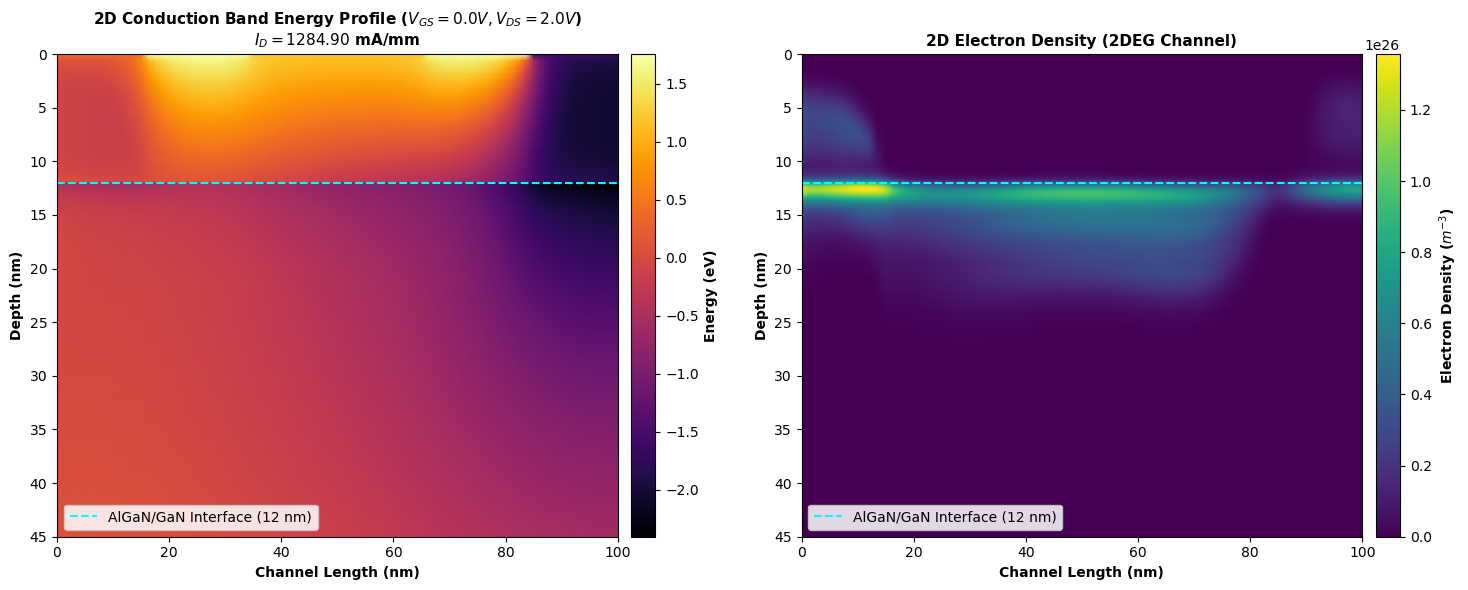

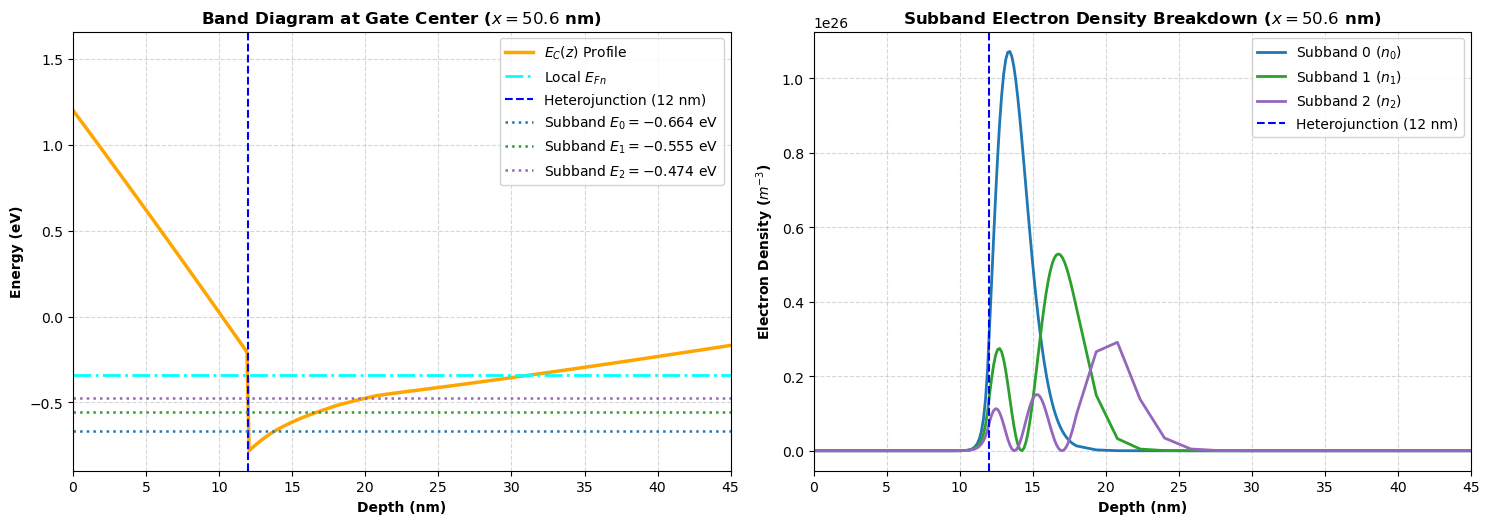

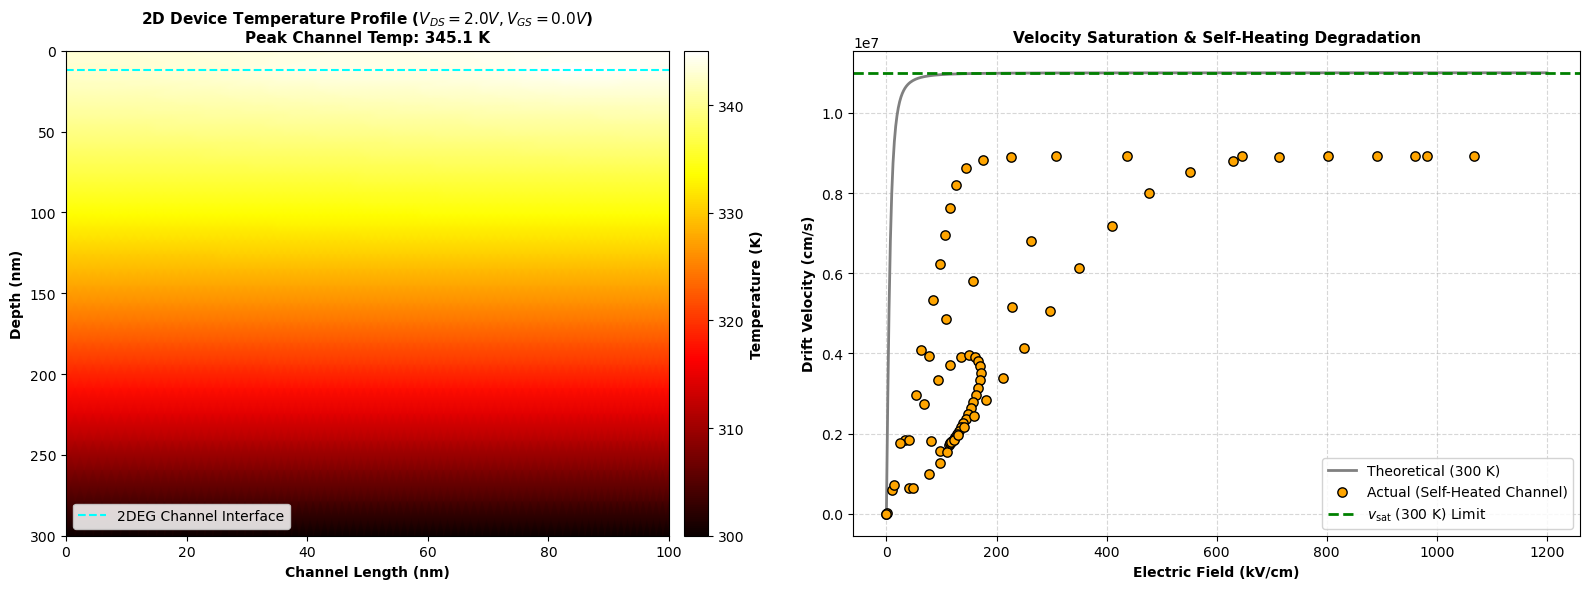

In [8]:
# 6. PLOTS FOR VISUALISATION
x_nm = x * 1e9
z_nm = z * 1e9
E_C_2D_eV = (V_band - q * phi) / q
x_gc_nm = x_nm[i_gate_center]

# Depth limit for zoomed interface view (nm)
z_interface_limit_nm = 45.0  


# FIGURE 1: 2D Spatial Electronic Colour Contours
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: 2D Conduction Band Energy
im0 = axes1[0].pcolormesh(x_nm, z_nm, E_C_2D_eV, shading='gouraud', cmap='inferno')
axes1[0].axhline(y=t_barrier*1e9, color='cyan', linestyle='--', linewidth=1.5, label='AlGaN/GaN Interface (12 nm)')
axes1[0].set_title(f'2D Conduction Band Energy Profile ($V_{{GS}} = {Vg}V, V_{{DS}} = {Vds}V$)\n$I_D = {I_d_avg:.2f}$ mA/mm', fontsize=11, fontweight='bold')
axes1[0].set_xlabel('Channel Length (nm)', fontweight='bold')
axes1[0].set_ylabel('Depth (nm)', fontweight='bold')
axes1[0].set_ylim(z_interface_limit_nm, 0)  # Inverted & zoomed to top 45 nm
cbar0 = fig1.colorbar(im0, ax=axes1[0], pad=0.02)
cbar0.set_label('Energy (eV)', fontweight='bold')
axes1[0].legend(loc='lower left', framealpha=0.85)

# Plot 2: 2D Electron Density
im1 = axes1[1].pcolormesh(x_nm, z_nm, n_2d, shading='gouraud', cmap='viridis')
axes1[1].axhline(y=t_barrier*1e9, color='cyan', linestyle='--', linewidth=1.5, label='AlGaN/GaN Interface (12 nm)')
axes1[1].set_title('2D Electron Density (2DEG Channel)', fontsize=11, fontweight='bold')
axes1[1].set_xlabel('Channel Length (nm)', fontweight='bold')
axes1[1].set_ylabel('Depth (nm)', fontweight='bold')
axes1[1].set_ylim(z_interface_limit_nm, 0)  # Inverted & zoomed to top 45 nm
cbar1 = fig1.colorbar(im1, ax=axes1[1], pad=0.02)
cbar1.set_label('Electron Density ($m^{-3}$)', fontweight='bold')
axes1[1].legend(loc='lower left', framealpha=0.85)

fig1.tight_layout()


# FIGURE 2: 1D Depth Profiles at Gate Center
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5.5))

# Plot 3: Conduction Band Profile along depth
E_C_gc_eV = E_C_2D_eV[:, i_gate_center]
E_Fn_gc_eV = -V_ef_lat[i_gate_center]

axes2[0].plot(z_nm, E_C_gc_eV, color='orange', linewidth=2.5, label='$E_C(z)$ Profile')
axes2[0].axhline(y=E_Fn_gc_eV, color='cyan', linestyle='-.', linewidth=2, label='Local $E_{Fn}$')
axes2[0].axvline(x=t_barrier*1e9, color='blue', linestyle='--', linewidth=1.5, label='Heterojunction (12 nm)')

colors_sub = ['tab:blue', 'tab:green', 'tab:purple']
for m in range(n_subbands):
    E_m_eV = evals_gate_center[m] / q
    axes2[0].axhline(y=E_m_eV, color=colors_sub[m], linestyle=':', linewidth=1.8, label=f'Subband $E_{m} = {E_m_eV:.3f}$ eV')

axes2[0].set_xlim(0, z_interface_limit_nm)  # Focus on quantum well region
axes2[0].set_title(f'Band Diagram at Gate Center ($x = {x_gc_nm:.1f}$ nm)', fontweight='bold', fontsize=12)
axes2[0].set_xlabel('Depth (nm)', fontweight='bold')
axes2[0].set_ylabel('Energy (eV)', fontweight='bold')
axes2[0].grid(True, linestyle='--', alpha=0.5)
axes2[0].legend(loc='upper right', framealpha=0.85)

# Plot 4: Subband Electron Densities along depth
for m in range(n_subbands):
    axes2[1].plot(z_nm, n_subbands_gate_center[m, :], color=colors_sub[m], linestyle='-', linewidth=2, label=f'Subband {m} ($n_{m}$)')

axes2[1].axvline(x=t_barrier*1e9, color='blue', linestyle='--', linewidth=1.5, label='Heterojunction (12 nm)')
axes2[1].set_xlim(0, z_interface_limit_nm)  # Focus on quantum well region near interface
axes2[1].set_title(f'Subband Electron Density Breakdown ($x = {x_gc_nm:.1f}$ nm)', fontweight='bold', fontsize=12)
axes2[1].set_xlabel('Depth (nm)', fontweight='bold')
axes2[1].set_ylabel('Electron Density ($m^{-3}$)', fontweight='bold')
axes2[1].grid(True, linestyle='--', alpha=0.5)
axes2[1].legend(loc='upper right', framealpha=0.85)

fig2.tight_layout()


# FIGURE 3: THERMAL HEATMAP & DRIFT VELOCITY
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))

# Subplot Left: 2D Temperature Profile Heatmap
im_temp = axes3[0].pcolormesh(x_nm, z_nm, T_2d, shading='gouraud', cmap='hot')
axes3[0].axhline(y=t_barrier*1e9, color='cyan', linestyle='--', linewidth=1.5, label='2DEG Channel Interface')
axes3[0].set_title(f'2D Device Temperature Profile ($V_{{DS}} = {Vds}V, V_{{GS}} = {Vg}V$)\nPeak Channel Temp: {np.max(T_2d):.1f} K', fontsize=11, fontweight='bold')
axes3[0].set_xlabel('Channel Length (nm)', fontweight='bold')
axes3[0].set_ylabel('Depth (nm)', fontweight='bold')
axes3[0].invert_yaxis()  # Standard semiconductor depth view
cbar_temp = fig3.colorbar(im_temp, ax=axes3[0], pad=0.02)
cbar_temp.set_label('Temperature (K)', fontweight='bold')
axes3[0].legend(loc='lower left', framealpha=0.85)

# Subplot Right: Velocity Saturation & Field Degradation Plot
E_field_grid = np.linspace(1e2, 1.2e8, 500)  # V/m
E_kV_cm = E_field_grid / 1e5                  # V/m -> kV/cm

den_theoretical = (1.0 + (mu_0 * E_field_grid / v_sat_300K)**beta_CT)**(1.0 / beta_CT)
v_theoretical_cm_s = (mu_0 * E_field_grid / den_theoretical) * 100.0  # m/s -> cm/s

Ex_kV_cm = Ex_abs / 1e5
v_drift_actual_cm_s = (mu_field * Ex_abs) * 100.0

axes3[1].plot(E_kV_cm, v_theoretical_cm_s, color='gray', linewidth=2, label='Theoretical (300 K)')
axes3[1].scatter(Ex_kV_cm, v_drift_actual_cm_s, color='orange', edgecolors='black', s=45, zorder=5, label='Actual (Self-Heated Channel)')
axes3[1].axhline(y=v_sat_300K * 100.0, color='green', linestyle='--', linewidth=2, label='$v_{\\mathrm{sat}}$ (300 K) Limit')

axes3[1].set_title('Velocity Saturation & Self-Heating Degradation', fontweight='bold', fontsize=11)
axes3[1].set_xlabel('Electric Field (kV/cm)', fontweight='bold')
axes3[1].set_ylabel('Drift Velocity (cm/s)', fontweight='bold')
axes3[1].grid(True, linestyle='--', alpha=0.5)
axes3[1].legend(loc='lower right', framealpha=0.85)

fig3.tight_layout()

plt.show()